# Sprint 1 — PubMedQA Baseline RAG Experiment

## Research Question

**Does providing relevant retrieved context improve an LLM's answer quality compared with answering the same question without retrieved context?**

This notebook presents the PubMedQA baseline experiment for Sprint 1 of the **Context Matters** project.

The experiment compares three language models:

- Llama 3.3 70B
- Gemma 4 26B
- Ministral 3 14B

For each model, we compare:

- **WITHOUT_CONTEXT** — the model answers the question using only its own knowledge.
- **WITH_CONTEXT** — the model receives the same question together with the Top-5 passages retrieved from the PubMedQA corpus.

Four retrieval methods are evaluated:

- BM25
- DPR
- Contriever
- ColBERTv2

Sprint 1 uses only the standard relevance-ranked Top-5 passages.  
No retrieval diversification method is applied in this notebook.

The purpose of this baseline is to establish how much ordinary RAG helps before diversity-aware retrieval methods such as MMR, clustering, and DPP are introduced in later experiments.

---

### What this notebook will show

The notebook evaluates:

1. how well each retriever finds relevant PubMedQA evidence;
2. whether retrieved context improves answer correctness;
3. whether the effect differs across the three LLMs;
4. whether different retrievers lead to different answer quality;
5. how well answers are supported by the retrieved evidence;
6. uncertainty in the observed differences using paired statistical analysis.

All individual experimental results are stored outside the notebook as structured artifacts.  
This notebook loads those artifacts and presents the results using tables, figures, and simple interpretations.

## Reproducibility and How to Run This Notebook

This notebook is designed to run from top to bottom inside the **Context Matters** project repository.

The notebook does not rebuild large retrieval indexes or automatically repeat thousands of external LLM requests. Those expensive experimental steps are executed using the governed project scripts and their outputs are stored as structured artifacts.

When this notebook is run, it:

1. installs the small Python packages required for analysis and visualization;
2. verifies the Python and GPU environment;
3. locates the project repository automatically;
4. loads the frozen PubMedQA dataset configuration;
5. validates the saved retrieval and context artifacts;
6. reconstructs per-query evaluation results;
7. loads saved LLM generation and evaluation results when they are available;
8. produces tables, statistical comparisons, and figures.

### Reproduction requirement

A user should be able to:

**Restart the kernel → Run All Cells**

and reproduce the analysis without manually creating variables or changing file paths.

The notebook expects to be executed from within the project repository and requires access to the saved scientific artifacts under `artifacts/` and `results/`.

Large model-generation experiments require separate authenticated access to the Mannheim Maki service and are therefore not automatically triggered by this notebook.

In [1]:
%pip install -q pandas pyarrow matplotlib datasets rank-bm25

Note: you may need to restart the kernel to use updated packages.


In [2]:
import sys
import platform
import torch

print("Python executable:", sys.executable)
print("Python version:", platform.python_version())
print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("GPU: Not available")

Python executable: /workspace/venvs/context-matters-cu130/bin/python
Python version: 3.12.3
PyTorch version: 2.13.0+cu130
CUDA available: True
GPU: NVIDIA GeForce RTX 5090


In [3]:
from pathlib import Path
import sys

def find_repo_root():
    start = Path.cwd().resolve()

    for path in [start, *start.parents]:
        has_src = (path / "src").exists()
        has_scripts = (path / "scripts").exists()
        has_blueprint = (
            path / "docs" / "EXPERIMENT_RESULTS_BLUEPRINT.md"
        ).exists()

        if has_src and has_scripts and has_blueprint:
            return path

    raise RuntimeError(
        "Context Matters project repository could not be found. "
        "Open this notebook from inside the project repository."
    )

ROOT = find_repo_root()
SRC = ROOT / "src"

for path in [ROOT, SRC]:
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

print("Repository root:", ROOT)
print("Project imports enabled:", str(ROOT) in sys.path)

Repository root: /workspace/context-matters-rag-sprint3-current
Project imports enabled: True


## PubMedQA Dataset

PubMedQA is a biomedical question-answering dataset built from PubMed articles.

In this project, each question is associated with one or more context sections from the corresponding PubMed article. These context sections form the retrieval corpus used by the four retrievers.

For the current controlled Sprint 1 baseline:

- **Questions:** 1,000
- **Corpus passages:** 3,358
- **Task:** predict the final PubMedQA decision (`yes`, `no`, or `maybe`)
- **Retrievers:** BM25, DPR, Contriever, and ColBERTv2
- **Candidate pool:** Top-20 retrieved passages
- **Context given to the LLM:** Top-5 passages

### Evidence role

The complete PubMedQA PQA-L1000 set was already used in the historical Sprint 1 work.

Therefore, the current controlled PubMedQA experiment is treated as an:

**HISTORICAL_OBSERVED_CONTROL_REPLICATION**

This means PubMedQA is still useful for comparing retrievers, LLMs, context conditions, faithfulness, and later diversification methods, but it is not treated as previously unseen protected-final evidence.

The historical Sprint 1 results remain preserved separately. The results presented in this notebook come from the current controlled experimental pipeline.

## Experimental Design

Sprint 1 establishes the standard relevance-based RAG baseline before any diversification method is introduced.

The experiment uses:

### Language models

- Llama 3.3 70B
- Gemma 4 26B
- Ministral 3 14B

### Retrievers

- BM25
- DPR
- Contriever
- ColBERTv2

### Context conditions

Each language model is evaluated in two ways:

**WITHOUT_CONTEXT**

The model receives only the PubMedQA question.

**WITH_CONTEXT**

The model receives the same question together with the Top-5 passages retrieved by one of the four retrievers.

This produces the following conditions for each LLM:

1. WITHOUT_CONTEXT
2. BM25 WITH_CONTEXT
3. DPR WITH_CONTEXT
4. Contriever WITH_CONTEXT
5. ColBERTv2 WITH_CONTEXT

For 1,000 PubMedQA questions and 3 LLMs, the complete Sprint 1 PubMedQA baseline therefore contains:

- **3,000 WITHOUT_CONTEXT generations**
- **12,000 WITH_CONTEXT generations**
- **15,000 generations in total**

### Controlled comparison

The purpose of the experiment is to change as little as possible between conditions.

Within each comparison, the following are kept fixed:

- dataset and question
- language model
- prompt format
- decoding settings
- answer format
- evaluation procedure

The main factor that changes is whether retrieved context is provided and, for WITH_CONTEXT runs, which retriever produced that context.

This allows us to study whether retrieval helps the model rather than mixing the effect of retrieval with unrelated pipeline changes.

No MMR, clustering, DPP, or other diversification method is used in Sprint 1.

## Retrieval Methods

Sprint 1 compares four different retrieval approaches.

The goal is not to assume that one retriever is always best. Instead, we compare how different retrieval strategies affect both evidence retrieval and downstream LLM answers.

### BM25

BM25 is a traditional keyword-based retrieval method.

It gives higher scores to passages that share important words with the question.

**Strength:** simple, fast, and strong when the question and relevant passage use similar words.

**Limitation:** it may miss relevant passages when the same meaning is expressed using different wording.

---

### DPR

DPR stands for **Dense Passage Retrieval**.

Instead of matching exact words, DPR converts questions and passages into dense vector representations and retrieves passages that are close in the embedding space.

**Strength:** can retrieve semantically related passages even when the wording is different.

**Limitation:** retrieval quality depends strongly on how well the pretrained representation matches the target domain.

---

### Contriever

Contriever is also a dense retriever.

It represents questions and passages as embeddings, but it was trained using unsupervised contrastive learning rather than relying on task-specific retrieval supervision.

**Strength:** general-purpose semantic retrieval and good transfer across domains.

**Limitation:** performance can still vary depending on the dataset and corpus.

---

### ColBERTv2

ColBERTv2 uses a more fine-grained interaction between the tokens of the question and the tokens of each passage.

Instead of representing the entire question and passage with only one vector, it keeps token-level representations and performs late interaction during retrieval.

**Strength:** can capture detailed matching signals while still using semantic representations.

**Limitation:** indexing and retrieval are more computationally expensive than simpler methods such as BM25.

---

### Why compare all four?

These retrievers represent different retrieval strategies:

- **BM25:** lexical matching
- **DPR:** supervised dense retrieval
- **Contriever:** unsupervised dense retrieval
- **ColBERTv2:** token-level late interaction

Comparing them helps us understand whether the type of retrieval method influences both the evidence retrieved and the final RAG answer.

## Retrieval Evaluation Metrics

Before looking at the retrieval results, we define the metrics used to evaluate how well each retriever finds relevant PubMedQA evidence.

### Recall@5

Recall@5 measures how much of the relevant evidence is found within the first five retrieved passages.

For one question:

\[
\text{Recall@5} =
\frac{\text{number of relevant passages in the Top-5}}
{\text{total number of relevant passages}}
\]

A higher value means the retriever recovered more of the available relevant evidence within the context window that is actually shown to the LLM.

For example:

- Recall@5 = 1.0 means all relevant passages were found in the Top-5.
- Recall@5 = 0.5 means half of the relevant passages were found.
- Recall@5 = 0 means none of the relevant passages were found.

---

### MRR@5

MRR stands for **Mean Reciprocal Rank**.

It measures how early the first relevant passage appears in the ranking.

For one question:

- first relevant passage at rank 1 → reciprocal rank = 1.0
- first relevant passage at rank 2 → reciprocal rank = 0.5
- first relevant passage at rank 5 → reciprocal rank = 0.2
- no relevant passage in the Top-5 → reciprocal rank = 0

The final MRR@5 is the average across all questions.

A high MRR@5 means the retriever usually places at least one relevant passage very near the top.

---

### Candidate Recall@20

Candidate Recall@20 measures how much relevant evidence is present anywhere in the Top-20 candidate pool.

This metric is important because later diversification methods operate on the same Top-20 candidates.

If relevant evidence is already missing from the Top-20, no diversification method can recover it later.

Therefore:

- **Recall@5** measures the quality of the final context shown to the LLM.
- **MRR@5** measures how early the first relevant passage appears.
- **Candidate Recall@20** measures how much useful evidence is available before later selection or diversification.

In [4]:
import os
from pathlib import Path

from datasets import load_dataset

from scripts.build_corpus_manifests import (
    PUBMEDQA_SOURCE,
    PUBMEDQA_CONFIG,
    PUBMEDQA_SPLIT,
    PUBMEDQA_REVISION,
    PUBMEDQA_SAMPLE_MANIFEST_PATH,
    load_frozen_pubmedqa_sample_manifest,
    build_pubmedqa_corpus_manifest,
)

# Use an existing Hugging Face cache when available.
# This keeps the notebook portable while reusing the RunPod cache efficiently.
cache_candidates = [
    Path(os.environ["HF_HOME"]) if "HF_HOME" in os.environ else None,
    Path("/workspace/.cache/huggingface"),
    Path.home() / ".cache" / "huggingface",
]

HF_CACHE = next(
    (path for path in cache_candidates if path is not None and path.exists()),
    Path.home() / ".cache" / "huggingface",
)

HF_CACHE.mkdir(parents=True, exist_ok=True)

print("Hugging Face cache:", HF_CACHE)

# Load the exact pinned PubMedQA revision used by the project.
dataset_rows = load_dataset(
    PUBMEDQA_SOURCE,
    PUBMEDQA_CONFIG,
    split=PUBMEDQA_SPLIT,
    revision=PUBMEDQA_REVISION,
    cache_dir=str(HF_CACHE),
)

# Load the frozen sample manifest from the repository.
sample_manifest = load_frozen_pubmedqa_sample_manifest(
    PUBMEDQA_SAMPLE_MANIFEST_PATH
)

# Reconstruct and validate the canonical PubMedQA corpus.
corpus_build = build_pubmedqa_corpus_manifest(
    tuple(dataset_rows),
    sample_manifest,
)

gold_by_sample = corpus_build.gold_document_ids_by_sample

print("\nValidation successful")
print("---------------------")
print("Questions:", len(gold_by_sample))
print("Corpus passages:", len(corpus_build.corpus_records))
print("Sample manifest:", sample_manifest.manifest_id)
print("Corpus manifest:", corpus_build.corpus_manifest.corpus_manifest_id)

/workspace/venvs/context-matters-cu130/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Hugging Face cache: /workspace/.cache/huggingface



Validation successful
---------------------
Questions: 1000
Corpus passages: 3358
Sample manifest: sample-manifest:sha256:4704a5250f52144a38b7f4734f887fe11f5bad18198c285fb048b21d414387ff
Corpus manifest: corpus-manifest:sha256:e4a9d368c9b3d4270e6bcc721e2e0e8d807d47891ac6039d866ea1c6e44b2a43


## Retrieval Artifact Validation

The four retrievers were executed before this analysis notebook was created.

For each PubMedQA question, the project stores:

- the Top-20 retrieved candidate passages;
- their exact ranking;
- retriever scores;
- document identities;
- content hashes;
- retriever and corpus provenance.

For the RAG baseline, the first five passages from each Top-20 ranking are also stored as a separate **selected-context artifact**.

Before calculating retrieval metrics, this notebook verifies that all expected artifacts are present.

For 1,000 questions and four retrievers, we expect:

- **4,000 Top-20 candidate artifacts**
- **4,000 Top-5 selected-context artifacts**

This validation is important because missing retrieval results must not be silently ignored or treated as zero.

In [6]:
import json
from pathlib import Path

CANDIDATE_ROOT = ROOT / "artifacts" / "candidates"
CONTEXT_ROOT = ROOT / "artifacts" / "selected_contexts"


def inspect_one_artifact(root):
    for path in root.rglob("*.json"):
        try:
            with path.open("r", encoding="utf-8") as f:
                obj = json.load(f)
        except (json.JSONDecodeError, OSError):
            continue

        payload = obj.get("scientific_payload")

        if isinstance(payload, dict):
            print("File:", path)
            print("\nTop-level keys:")
            print(list(obj.keys()))

            print("\nScientific payload keys:")
            print(list(payload.keys()))

            print("\nImportant field types:")
            for key in [
                "dataset",
                "sample_id",
                "retriever",
                "requested_top_n",
                "candidate_pool",
                "top_k",
                "method",
            ]:
                if key in payload:
                    value = payload[key]
                    print(
                        f"{key}: type={type(value).__name__}, "
                        f"value={value if not isinstance(value, dict) else list(value.keys())}"
                    )

            return

    raise RuntimeError(f"No scientific artifact found under {root}")


print("=== Candidate artifact ===")
inspect_one_artifact(CANDIDATE_ROOT)

print("\n=== Selected-context artifact ===")
inspect_one_artifact(CONTEXT_ROOT)

=== Candidate artifact ===
File: /workspace/context-matters-rag-sprint3-current/artifacts/candidates/sets/pubmedqa/colbertv2_candidate_set_v1.json

Top-level keys:
['artifact_format', 'candidate_set_id', 'provenance', 'scientific_payload', 'scientific_sha256']

Scientific payload keys:
['dataset', 'entries', 'evidence_role', 'expected_query_count', 'retriever', 'sample_manifest_id', 'schema_version']

Important field types:
dataset: type=str, value=pubmedqa
retriever: type=str, value=colbertv2

=== Selected-context artifact ===
File: /workspace/context-matters-rag-sprint3-current/artifacts/selected_contexts/sets/pubmedqa/colbertv2_selected_context_set_v1.json

Top-level keys:
['artifact_format', 'provenance', 'scientific_payload', 'scientific_sha256', 'selected_context_set_id']

Scientific payload keys:
['candidate_pool', 'candidate_set_id', 'dataset', 'entries', 'evidence_role', 'expected_query_count', 'method', 'retriever', 'sample_manifest_id', 'schema_version', 'top_k']

Important 

In [7]:
import json

candidate_set_path = (
    ROOT
    / "artifacts"
    / "candidates"
    / "sets"
    / "pubmedqa"
    / "bm25_candidate_set_v1.json"
)

context_set_path = (
    ROOT
    / "artifacts"
    / "selected_contexts"
    / "sets"
    / "pubmedqa"
    / "bm25_selected_context_set_v1.json"
)


def inspect_entries(path):
    with path.open("r", encoding="utf-8") as f:
        obj = json.load(f)

    payload = obj["scientific_payload"]
    entries = payload["entries"]

    print("File:", path.name)
    print("Expected query count:", payload["expected_query_count"])
    print("Number of entries:", len(entries))

    print("\nFirst entry:")
    print(entries[0])

    print("\nFirst entry type:", type(entries[0]).__name__)

    if isinstance(entries[0], dict):
        print("First entry keys:", list(entries[0].keys()))


print("=== Candidate set ===")
inspect_entries(candidate_set_path)

print("\n=== Selected-context set ===")
inspect_entries(context_set_path)

=== Candidate set ===
File: bm25_candidate_set_v1.json
Expected query count: 1000
Number of entries: 1000

First entry:
{'candidate_artifact_id': 'candidate:sha256:fc400c5883a4d7528bf63a2a0685a7e9fb7d3c5f7fbf30ac570aa12ee65a59e5', 'sample_id': 0}

First entry type: dict
First entry keys: ['candidate_artifact_id', 'sample_id']

=== Selected-context set ===
File: bm25_selected_context_set_v1.json
Expected query count: 1000
Number of entries: 1000

First entry:
{'sample_id': 0, 'selected_context_id': 'selected-context:sha256:436e57e90265f66c436f1dd9ae6dc208335599fefa088a7a652c8c1d883918a9'}

First entry type: dict
First entry keys: ['sample_id', 'selected_context_id']


In [8]:
import json
import pandas as pd

EXPECTED_RETRIEVERS = [
    "bm25",
    "dpr",
    "contriever",
    "colbertv2",
]

EXPECTED_QUESTIONS = 1000
EXPECTED_SAMPLE_IDS = set(range(EXPECTED_QUESTIONS))

CANDIDATE_SET_DIR = (
    ROOT
    / "artifacts"
    / "candidates"
    / "sets"
    / "pubmedqa"
)

CONTEXT_SET_DIR = (
    ROOT
    / "artifacts"
    / "selected_contexts"
    / "sets"
    / "pubmedqa"
)


def load_json(path):
    """Load one JSON artifact."""
    if not path.exists():
        raise FileNotFoundError(
            f"Required artifact is missing:\n{path}"
        )

    with path.open("r", encoding="utf-8") as f:
        return json.load(f)


validation_rows = []

for retriever in EXPECTED_RETRIEVERS:

    candidate_path = (
        CANDIDATE_SET_DIR
        / f"{retriever}_candidate_set_v1.json"
    )

    context_path = (
        CONTEXT_SET_DIR
        / f"{retriever}_selected_context_set_v1.json"
    )

    candidate_obj = load_json(candidate_path)
    context_obj = load_json(context_path)

    candidate_payload = candidate_obj["scientific_payload"]
    context_payload = context_obj["scientific_payload"]

    candidate_entries = candidate_payload["entries"]
    context_entries = context_payload["entries"]

    candidate_sample_ids = {
        int(entry["sample_id"])
        for entry in candidate_entries
    }

    context_sample_ids = {
        int(entry["sample_id"])
        for entry in context_entries
    }

    # ---------------------------------------------------------
    # Validate candidate-set metadata
    # ---------------------------------------------------------

    assert candidate_payload["dataset"] == "pubmedqa"
    assert candidate_payload["retriever"] == retriever

    assert (
        candidate_payload["expected_query_count"]
        == EXPECTED_QUESTIONS
    )

    assert (
        candidate_payload["sample_manifest_id"]
        == sample_manifest.manifest_id
    )

    # ---------------------------------------------------------
    # Validate selected-context metadata
    # ---------------------------------------------------------

    assert context_payload["dataset"] == "pubmedqa"
    assert context_payload["retriever"] == retriever

    assert (
        context_payload["expected_query_count"]
        == EXPECTED_QUESTIONS
    )

    assert (
        context_payload["sample_manifest_id"]
        == sample_manifest.manifest_id
    )

    assert context_payload["candidate_pool"] == 20
    assert context_payload["top_k"] == 5
    assert context_payload["method"] == "none"

    # The selected contexts must come from this exact
    # candidate set.
    assert (
        context_payload["candidate_set_id"]
        == candidate_obj["candidate_set_id"]
    )

    # ---------------------------------------------------------
    # Validate sample completeness
    # ---------------------------------------------------------

    assert len(candidate_entries) == EXPECTED_QUESTIONS
    assert len(context_entries) == EXPECTED_QUESTIONS

    assert candidate_sample_ids == EXPECTED_SAMPLE_IDS
    assert context_sample_ids == EXPECTED_SAMPLE_IDS

    assert candidate_sample_ids == context_sample_ids

    # Every entry must point to a scientific artifact.
    assert all(
        entry.get("candidate_artifact_id")
        for entry in candidate_entries
    )

    assert all(
        entry.get("selected_context_id")
        for entry in context_entries
    )

    validation_rows.append(
        {
            "Retriever": retriever,
            "Top-20 candidate results": len(candidate_entries),
            "Top-5 selected contexts": len(context_entries),
            "Validation": "PASS",
        }
    )


artifact_check = pd.DataFrame(validation_rows)

display(artifact_check)

print("\nRetrieval artifact validation passed.")
print(
    "Total Top-20 candidate results:",
    artifact_check["Top-20 candidate results"].sum(),
)
print(
    "Total Top-5 selected contexts:",
    artifact_check["Top-5 selected contexts"].sum(),
)

,Retriever,Top-20 candidate results,Top-5 selected contexts,Validation
0,bm25,1000,1000,PASS
1,dpr,1000,1000,PASS
2,contriever,1000,1000,PASS
3,colbertv2,1000,1000,PASS



Retrieval artifact validation passed.
Total Top-20 candidate results: 4000
Total Top-5 selected contexts: 4000


## Calculating Retrieval Quality

We now evaluate how well each retriever finds the evidence associated with each PubMedQA question.

The evaluation is first performed **separately for every question**.

For each question, we compare:

- the gold evidence passages defined by the frozen PubMedQA mapping;
- the retriever's Top-20 candidate ranking;
- the first five passages selected as context for the LLM.

From this comparison, three retrieval metrics are calculated.

### Recall@5

Recall@5 measures the fraction of the question's gold evidence passages that appear within the Top-5 retrieved passages.

$$
\text{Recall@5}
=
\frac{\text{Number of gold passages found in the Top-5}}
{\text{Total number of gold passages}}
$$

For example:

- `1.0` means all gold evidence passages were retrieved in the Top-5;
- `0.5` means half of the gold evidence passages were retrieved;
- `0.0` means none of the gold evidence passages were retrieved.

Recall@5 is especially important for this RAG experiment because the Top-5 passages form the context that is actually provided to the language model.

---

### MRR@5

MRR stands for **Mean Reciprocal Rank**.

For each question, we first find the rank of the earliest gold evidence passage within the Top-5.

The reciprocal rank for that question is:

$$
\text{Reciprocal Rank}
=
\frac{1}
{\text{Rank of the first relevant passage}}
$$

For example:

- first relevant passage at rank 1 → `1.0`
- first relevant passage at rank 2 → `0.5`
- first relevant passage at rank 5 → `0.2`
- no relevant passage in the Top-5 → `0.0`

MRR@5 is the mean of these per-question reciprocal-rank values across all questions.

A higher MRR@5 means that relevant evidence tends to appear earlier in the ranking.

---

### Candidate Recall@20

Candidate Recall@20 measures the fraction of gold evidence passages that appear anywhere within the Top-20 candidate pool.

$$
\text{Candidate Recall@20}
=
\frac{\text{Number of gold passages found in the Top-20}}
{\text{Total number of gold passages}}
$$

This is important because the diversity-aware retrieval methods used in later sprints select passages from this candidate pool.

A diversification method can reorganize or select from the available Top-20 passages, but it cannot recover relevant evidence that was never retrieved into the candidate pool.

Therefore:

- **Recall@5** measures the quality of the final retrieved context;
- **MRR@5** measures how early relevant evidence appears;
- **Candidate Recall@20** measures the amount of relevant evidence available before later selection or diversification.

---

### Per-question evaluation

The notebook preserves the metric values for every individual question instead of storing only final averages.

This is important because per-question results are required later for:

- confidence intervals;
- paired statistical comparisons;
- error analysis;
- identifying questions where retrieval succeeds or fails.

The aggregate retrieval results shown later are therefore summaries of the underlying per-question evidence.

In [9]:
import json
import pandas as pd


def load_candidate_artifacts(candidate_root):
    """
    Build a mapping from candidate artifact ID to the
    corresponding governed candidate artifact.
    """
    artifacts = {}

    for path in candidate_root.rglob("*.json"):
        try:
            with path.open("r", encoding="utf-8") as f:
                obj = json.load(f)
        except (json.JSONDecodeError, OSError):
            continue

        artifact_id = obj.get("artifact_id")

        if (
            isinstance(artifact_id, str)
            and artifact_id.startswith("candidate:sha256:")
            and isinstance(obj.get("scientific_payload"), dict)
        ):
            artifacts[artifact_id] = obj

    return artifacts


def recall_at_k(ranked_document_ids, gold_document_ids, k):
    """Fraction of gold documents retrieved within the first k ranks."""
    gold = set(gold_document_ids)

    if not gold:
        raise ValueError("Gold evidence set must not be empty.")

    retrieved = set(ranked_document_ids[:k])

    return len(gold & retrieved) / len(gold)


def reciprocal_rank_at_k(ranked_document_ids, gold_document_ids, k):
    """Reciprocal rank of the first gold document within the first k ranks."""
    gold = set(gold_document_ids)

    for rank, document_id in enumerate(
        ranked_document_ids[:k],
        start=1,
    ):
        if document_id in gold:
            return 1.0 / rank

    return 0.0


candidate_artifact_map = load_candidate_artifacts(
    ROOT / "artifacts" / "candidates"
)

print(
    "Governed candidate artifacts found:",
    len(candidate_artifact_map),
)


retrieval_rows = []

for retriever in EXPECTED_RETRIEVERS:

    candidate_set_path = (
        CANDIDATE_SET_DIR
        / f"{retriever}_candidate_set_v1.json"
    )

    candidate_set = load_json(candidate_set_path)
    entries = candidate_set["scientific_payload"]["entries"]

    for entry in entries:

        sample_id = int(entry["sample_id"])
        candidate_artifact_id = entry["candidate_artifact_id"]

        if candidate_artifact_id not in candidate_artifact_map:
            raise FileNotFoundError(
                "Candidate artifact referenced by the governed set "
                f"could not be found:\n{candidate_artifact_id}"
            )

        artifact = candidate_artifact_map[
            candidate_artifact_id
        ]

        payload = artifact["scientific_payload"]

        assert int(payload["sample_id"]) == sample_id

        candidates = sorted(
            payload["candidates"],
            key=lambda x: int(x["rank"]),
        )

        ranked_document_ids = [
            str(candidate["document_id"])
            for candidate in candidates
        ]

        if len(ranked_document_ids) != 20:
            raise ValueError(
                f"{retriever}, sample {sample_id}: "
                f"expected 20 candidates but found "
                f"{len(ranked_document_ids)}."
            )

        gold_document_ids = {
            str(document_id)
            for document_id in gold_by_sample[sample_id]
        }

        retrieval_rows.append(
            {
                "dataset": "pubmedqa",
                "sample_id": sample_id,
                "retriever": retriever,
                "gold_document_count": len(gold_document_ids),
                "recall_at_5": recall_at_k(
                    ranked_document_ids,
                    gold_document_ids,
                    5,
                ),
                "mrr_at_5": reciprocal_rank_at_k(
                    ranked_document_ids,
                    gold_document_ids,
                    5,
                ),
                "candidate_recall_at_20": recall_at_k(
                    ranked_document_ids,
                    gold_document_ids,
                    20,
                ),
                "candidate_artifact_id": candidate_artifact_id,
            }
        )


retrieval_per_query = pd.DataFrame(retrieval_rows)

assert len(retrieval_per_query) == 4000

assert (
    retrieval_per_query
    .groupby("retriever")["sample_id"]
    .nunique()
    .eq(1000)
    .all()
)

assert retrieval_per_query[
    [
        "recall_at_5",
        "mrr_at_5",
        "candidate_recall_at_20",
    ]
].notna().all().all()


print("\nPer-question retrieval evaluation complete.")
print("Rows:", len(retrieval_per_query))
print(
    "Questions per retriever:",
    retrieval_per_query
    .groupby("retriever")["sample_id"]
    .nunique()
    .to_dict(),
)

display(retrieval_per_query.head())

Governed candidate artifacts found: 4000

Per-question retrieval evaluation complete.
Rows: 4000
Questions per retriever: {'bm25': 1000, 'colbertv2': 1000, 'contriever': 1000, 'dpr': 1000}


,dataset,sample_id,retriever,gold_document_count,recall_at_5,mrr_at_5,candidate_recall_at_20,candidate_artifact_id
0,pubmedqa,0,bm25,2,1.000000,1.0,1.000000,candidate:sha256:fc400c5883a4d7528bf63a2a0685a...
1,pubmedqa,1,bm25,3,1.000000,1.0,1.000000,candidate:sha256:852fdccacde997f57f8c7afa23aa0...
2,pubmedqa,10,bm25,3,1.000000,1.0,1.000000,candidate:sha256:b9e9c11111e75972ebbd8ffbba351...
3,pubmedqa,100,bm25,4,0.750000,1.0,0.750000,candidate:sha256:f4112e06524ca984318e9ca1feba3...
4,pubmedqa,101,bm25,3,0.333333,1.0,0.333333,candidate:sha256:efa33c3a4f2315ceaa9891d19e9b2...


## Aggregate Retrieval Results

The previous step calculated retrieval quality separately for every PubMedQA question and retriever.

We now summarize those per-question results to obtain the average performance of each retrieval method across all 1,000 questions.

For each retriever, we report:

- **Recall@5** — average fraction of gold evidence retrieved within the final Top-5 context;
- **MRR@5** — average position of the first relevant passage;
- **Candidate Recall@20** — average fraction of gold evidence available in the Top-20 candidate pool.

These averages provide a compact comparison between the four retrievers.

However, the underlying per-question results are retained and will later be used for uncertainty estimation, statistical analysis, and error analysis.

The retrieval results alone do not tell us whether an LLM will produce a better answer. They only measure the quality of the evidence retrieved. Downstream answer quality is evaluated separately later in the notebook.

In [10]:
retrieval_summary = (
    retrieval_per_query
    .groupby("retriever", as_index=False)
    .agg(
        questions=("sample_id", "nunique"),
        recall_at_5=("recall_at_5", "mean"),
        mrr_at_5=("mrr_at_5", "mean"),
        candidate_recall_at_20=("candidate_recall_at_20", "mean"),
    )
    .sort_values(
        "recall_at_5",
        ascending=False,
    )
    .reset_index(drop=True)
)

# Basic validation
assert len(retrieval_summary) == 4
assert (retrieval_summary["questions"] == 1000).all()

display(
    retrieval_summary.style.format(
        {
            "recall_at_5": "{:.4f}",
            "mrr_at_5": "{:.4f}",
            "candidate_recall_at_20": "{:.4f}",
        }
    )
)

,retriever,questions,recall_at_5,mrr_at_5,candidate_recall_at_20
0,contriever,1000,0.7404,0.9721,0.8367
1,colbertv2,1000,0.7382,0.9762,0.8253
2,bm25,1000,0.5992,0.9115,0.7024
3,dpr,1000,0.3253,0.5787,0.4653


## Interpretation of Retrieval Results

The four retrievers show noticeably different retrieval behaviour on PubMedQA.

### Contriever

Contriever achieves the highest **Recall@5**:

- Recall@5 = **0.7404**
- MRR@5 = **0.9721**
- Candidate Recall@20 = **0.8367**

This means that, on average, Contriever retrieves about **74% of the gold evidence passages within the Top-5** and about **84% within the Top-20 candidate pool**.

Contriever therefore provides the highest average evidence coverage among the four retrievers in this experiment.

---

### ColBERTv2

ColBERTv2 performs very similarly to Contriever:

- Recall@5 = **0.7382**
- MRR@5 = **0.9762**
- Candidate Recall@20 = **0.8253**

Its Recall@5 is slightly lower than Contriever, but it achieves the highest **MRR@5**.

This indicates that ColBERTv2 is especially strong at placing at least one relevant passage very near the top of the ranking.

The difference between Contriever and ColBERTv2 in Recall@5 is very small, so this table alone should not be used to claim that one is meaningfully better than the other.

---

### BM25

BM25 achieves:

- Recall@5 = **0.5992**
- MRR@5 = **0.9115**
- Candidate Recall@20 = **0.7024**

Its evidence coverage is lower than Contriever and ColBERTv2, but its high MRR@5 shows that it still tends to place at least one relevant passage near the top.

This suggests that lexical matching remains useful for PubMedQA, even though it retrieves less of the total available gold evidence.

---

### DPR

DPR has the lowest retrieval scores:

- Recall@5 = **0.3253**
- MRR@5 = **0.5787**
- Candidate Recall@20 = **0.4653**

On average, DPR retrieves less than half of the available gold evidence even within the Top-20 candidate pool.

This gives later selection methods a more limited evidence pool to work with.

---

### Main observation

For this PubMedQA baseline, the descriptive ranking by Recall@5 is:

1. **Contriever — 0.7404**
2. **ColBERTv2 — 0.7382**
3. **BM25 — 0.5992**
4. **DPR — 0.3253**

However, these are retrieval-level results only.

A higher retrieval score does not automatically mean that the language model will produce a more correct or more faithful answer.

The next stages of the experiment therefore evaluate whether these differences in retrieved evidence also lead to differences in downstream RAG performance.

In [11]:
RESULT_DIR = (
    ROOT
    / "results"
    / "sprint1"
    / "pubmedqa"
)

FIGURE_DIR = RESULT_DIR / "figures"

RESULT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

FIGURE_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


# Save the complete per-question evidence.
retrieval_per_query.to_parquet(
    RESULT_DIR / "retrieval_per_query.parquet",
    index=False,
)

# Save a CSV copy for easy inspection.
retrieval_per_query.to_csv(
    RESULT_DIR / "retrieval_per_query.csv",
    index=False,
)

# Save the human-readable aggregate summary.
retrieval_summary.to_csv(
    RESULT_DIR / "retrieval_summary.csv",
    index=False,
)


print("Retrieval results saved successfully.")
print()
print(
    "Per-question Parquet:",
    RESULT_DIR / "retrieval_per_query.parquet",
)
print(
    "Per-question CSV:",
    RESULT_DIR / "retrieval_per_query.csv",
)
print(
    "Summary CSV:",
    RESULT_DIR / "retrieval_summary.csv",
)

Retrieval results saved successfully.

Per-question Parquet: /workspace/context-matters-rag-sprint3-current/results/sprint1/pubmedqa/retrieval_per_query.parquet
Per-question CSV: /workspace/context-matters-rag-sprint3-current/results/sprint1/pubmedqa/retrieval_per_query.csv
Summary CSV: /workspace/context-matters-rag-sprint3-current/results/sprint1/pubmedqa/retrieval_summary.csv


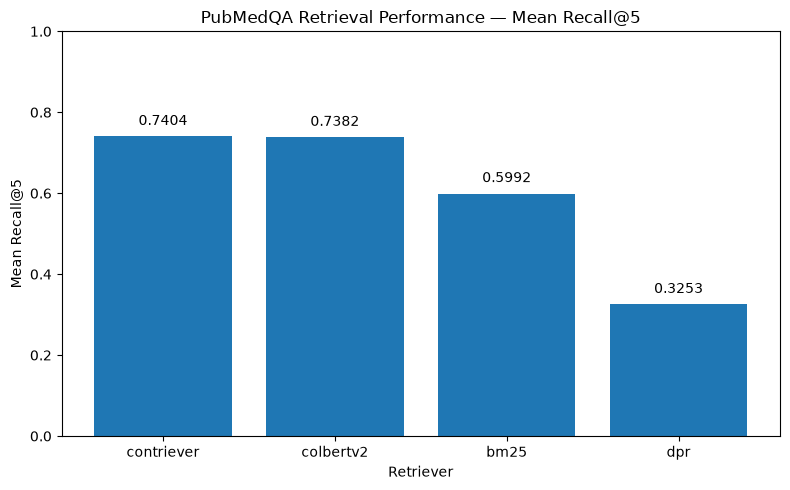

Figure saved: /workspace/context-matters-rag-sprint3-current/results/sprint1/pubmedqa/figures/pubmedqa_recall_at_5.png


In [12]:
import matplotlib.pyplot as plt

plot_data = retrieval_summary.sort_values(
    "recall_at_5",
    ascending=False,
).copy()

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    plot_data["retriever"],
    plot_data["recall_at_5"],
)

ax.set_title(
    "PubMedQA Retrieval Performance — Mean Recall@5"
)
ax.set_xlabel("Retriever")
ax.set_ylabel("Mean Recall@5")
ax.set_ylim(0, 1)

# Show the exact value above each bar.
for bar, value in zip(
    bars,
    plot_data["recall_at_5"],
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.02,
        f"{value:.4f}",
        ha="center",
        va="bottom",
    )

fig.tight_layout()

figure_path = (
    FIGURE_DIR
    / "pubmedqa_recall_at_5.png"
)

fig.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print("Figure saved:", figure_path)

### Interpretation of Mean Recall@5

The figure compares the average Recall@5 of the four retrievers across the same 1,000 PubMedQA questions.

The main observations are:

- **Contriever** achieves the highest mean Recall@5 at **0.7404**.
- **ColBERTv2** is almost identical at **0.7382**.
- **BM25** reaches **0.5992**.
- **DPR** has the lowest mean Recall@5 at **0.3253**.

Contriever and ColBERTv2 therefore retrieve substantially more of the available gold evidence within the final Top-5 context than BM25 and DPR.

However, the difference between Contriever and ColBERTv2 is very small:

\[
0.7404 - 0.7382 = 0.0022
\]

Therefore, this descriptive figure alone does not provide enough evidence to conclude that Contriever is meaningfully better than ColBERTv2.

BM25 retrieves less total gold evidence than Contriever and ColBERTv2, while DPR shows a considerably lower Recall@5 than the other three retrievers.

These results describe **retrieval quality only**. They do not yet tell us whether the retrieved passages improve the final LLM answers. That question is evaluated later using the WITH_CONTEXT and WITHOUT_CONTEXT experiments.

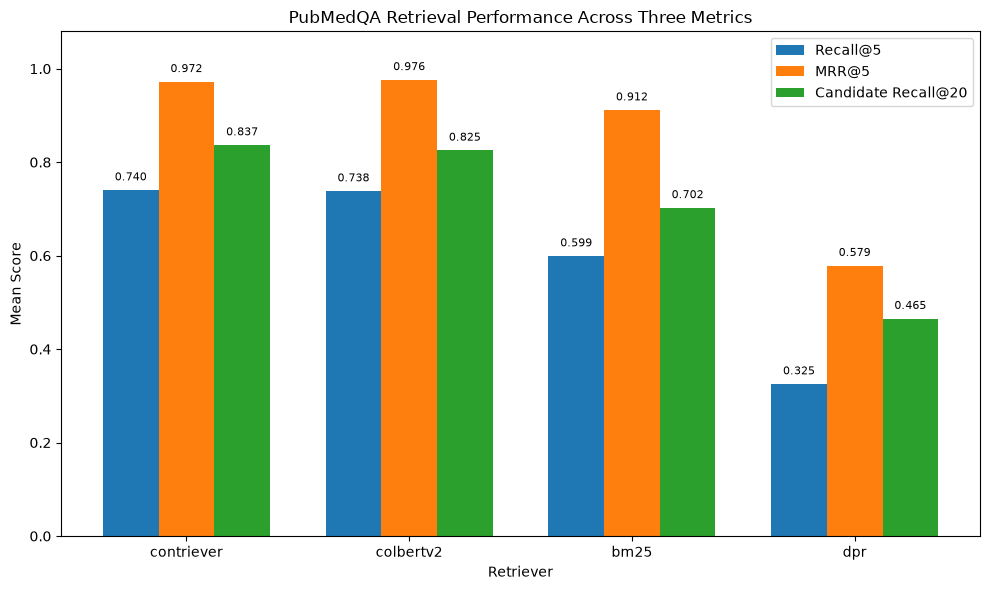

Figure saved: /workspace/context-matters-rag-sprint3-current/results/sprint1/pubmedqa/figures/pubmedqa_retrieval_metrics_comparison.png


In [13]:
import numpy as np
import matplotlib.pyplot as plt

# Keep the retrievers in the same order as the Recall@5 figure.
plot_data = (
    retrieval_summary
    .sort_values("recall_at_5", ascending=False)
    .reset_index(drop=True)
)

retrievers = plot_data["retriever"].tolist()

metrics = [
    ("recall_at_5", "Recall@5"),
    ("mrr_at_5", "MRR@5"),
    ("candidate_recall_at_20", "Candidate Recall@20"),
]

x = np.arange(len(retrievers))
bar_width = 0.25

fig, ax = plt.subplots(figsize=(10, 6))

for i, (column, label) in enumerate(metrics):

    positions = x + (i - 1) * bar_width

    bars = ax.bar(
        positions,
        plot_data[column],
        width=bar_width,
        label=label,
    )

    # Show the exact mean value above every bar.
    for bar, value in zip(bars, plot_data[column]):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.015,
            f"{value:.3f}",
            ha="center",
            va="bottom",
            fontsize=8,
        )

ax.set_title(
    "PubMedQA Retrieval Performance Across Three Metrics"
)

ax.set_xlabel("Retriever")
ax.set_ylabel("Mean Score")
ax.set_ylim(0, 1.08)

ax.set_xticks(x)
ax.set_xticklabels(retrievers)

ax.legend()

fig.tight_layout()

figure_path = (
    FIGURE_DIR
    / "pubmedqa_retrieval_metrics_comparison.png"
)

fig.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print("Figure saved:", figure_path)

### Interpretation of the Retrieval Metric Comparison

The three metrics describe different aspects of retrieval quality, and together they provide a more complete picture than Recall@5 alone.

### Contriever and ColBERTv2

Contriever and ColBERTv2 show the strongest overall retrieval performance.

Contriever achieves:

- Recall@5 = **0.740**
- MRR@5 = **0.972**
- Candidate Recall@20 = **0.837**

ColBERTv2 achieves:

- Recall@5 = **0.738**
- MRR@5 = **0.976**
- Candidate Recall@20 = **0.825**

Their Recall@5 values are almost identical.

Contriever retrieves slightly more of the total gold evidence within both the Top-5 and Top-20, while ColBERTv2 has the highest MRR@5.

This means that ColBERTv2 is slightly better at placing at least one relevant passage very early in the ranking, whereas Contriever provides slightly greater overall evidence coverage.

The differences between these two retrievers are small and should not be interpreted as meaningful superiority without uncertainty estimates or paired statistical analysis.

---

### BM25

BM25 achieves:

- Recall@5 = **0.599**
- MRR@5 = **0.912**
- Candidate Recall@20 = **0.702**

Its Recall values are lower than those of Contriever and ColBERTv2.

However, its MRR@5 remains high.

This indicates that BM25 frequently retrieves at least one relevant passage near the beginning of the ranking, even when it does not recover as much of the complete gold evidence.

---

### DPR

DPR achieves:

- Recall@5 = **0.325**
- MRR@5 = **0.579**
- Candidate Recall@20 = **0.465**

It performs substantially below the other three retrievers across all three retrieval metrics.

Its Candidate Recall@20 is particularly important for later experiments: on average, less than half of the available gold evidence is present in its Top-20 candidate pool.

This limits what later selection or diversification methods can recover from DPR's candidate set.

---

### Main takeaway

The retrieval experiment shows that the four retrieval methods do not provide the LLM with equally strong evidence.

For this PubMedQA experiment:

- Contriever provides the highest average evidence coverage;
- ColBERTv2 places relevant evidence slightly earlier on average;
- BM25 often finds relevant evidence early but retrieves less of the complete evidence;
- DPR provides the weakest evidence pool among the four retrievers.

These differences establish the retrieval baseline.

The next important question is whether these retrieval differences actually change the **correctness and faithfulness of the language model answers**.

## LLM Generation Experiment

After evaluating retrieval quality, we now study the effect of retrieved context on the final language-model answers.

The central question is:

**Does providing retrieved evidence improve answer quality compared with answering the same PubMedQA question without retrieved context?**

Three language models are evaluated:

- Llama 3.3 70B
- Gemma 4 26B
- Ministral 3 14B

For every PubMedQA question, each model is evaluated under two types of conditions.

### WITHOUT_CONTEXT

The model receives only the question.

No retrieved PubMedQA passages are provided.

This condition measures how well the model can answer using only its internal knowledge.

---

### WITH_CONTEXT

The model receives:

- the same PubMedQA question;
- the Top-5 passages retrieved by one of the four retrievers.

The four WITH_CONTEXT conditions are:

- BM25
- DPR
- Contriever
- ColBERTv2

This allows us to test whether retrieved evidence improves the answer and whether the result depends on the retriever used.

---

### Why both conditions are needed

A RAG system should not be judged only by how good its retrieval scores are.

The important question is whether the retrieved context actually helps the language model produce a better answer.

By comparing WITH_CONTEXT and WITHOUT_CONTEXT for the same question and the same language model, we can measure the effect of adding retrieved evidence while keeping the other experimental factors fixed.

---

### Number of generations

For each of the 1,000 PubMedQA questions:

- 3 WITHOUT_CONTEXT generations are produced;
- 12 WITH_CONTEXT generations are produced  
  (3 LLMs × 4 retrievers).

Therefore, the full PubMedQA baseline contains:

- **3,000 WITHOUT_CONTEXT generations**
- **12,000 WITH_CONTEXT generations**
- **15,000 generations in total**

The generation results are stored as structured artifacts and are loaded later in this notebook for evaluation.

## Generation Controls

To make the WITH_CONTEXT and WITHOUT_CONTEXT comparison fair, the generation setup is kept as consistent as possible.

Within each comparison, the following remain fixed:

- the PubMedQA question;
- the language model;
- the prompt structure;
- the decoding settings;
- the expected answer format;
- the evaluation procedure.

The main experimental change is whether retrieved evidence is included in the prompt.

### WITH_CONTEXT condition

For WITH_CONTEXT generations, the model receives the question together with the exact Top-5 passages selected by one retriever.

The passages are taken from the previously validated retrieval artifacts.

This means the generation step uses the same evidence that was evaluated in the retrieval section of this notebook.

### WITHOUT_CONTEXT condition

For WITHOUT_CONTEXT generations, the same question is used but no retrieved passages are included.

A WITHOUT_CONTEXT answer is generated once for each:

**question × language model**

It is not regenerated separately for BM25, DPR, Contriever, or ColBERTv2 because there is no retriever-specific context in this condition.

### Generation settings

The controlled generation configuration uses:

- **temperature:** 0
- **one canonical generation per condition**
- **maximum output length:** 256 tokens for PubMedQA
- **short structured answer format:** decision followed by a brief explanation

The expected PubMedQA decision is one of:

- `yes`
- `no`
- `maybe`

### Why these controls matter

If the prompt, decoding settings, or model changed between conditions, it would become difficult to determine whether differences in answer quality were caused by retrieval or by some other change.

Keeping these factors fixed makes the comparison easier to interpret:

**same question + same model + same generation settings, with retrieved context as the main changed factor.**

## Generation Status and Failure Handling

Not every model request is guaranteed to return a valid answer.

For this reason, each generation is stored together with an explicit status instead of assuming that every request succeeded.

The main statuses are:

- **OK** — a valid model response was returned;
- **REFUSAL** — the model refused to answer;
- **PARSE_FAILURE** — a response was returned, but it could not be interpreted in the expected answer format;
- **TRUNCATED** — the response was cut off because the maximum output length was reached;
- **ERROR** — the request failed because of an execution or service error.

### Why failures are stored explicitly

Failed generations are never silently converted into a score of zero and are never silently removed from the experiment.

Instead, the failure status is preserved so that we can distinguish between:

- an incorrect answer;
- a malformed answer;
- a refusal;
- a truncated response;
- a technical failure.

This is important because these situations have different meanings.

For example, a technically failed request should not be interpreted as evidence that the language model answered the question incorrectly.

### Retry policy

Infrastructure-related failures may be retried up to three times.

However, if the model successfully returns a response that is malformed or unsuitable for parsing, the content is preserved rather than repeatedly regenerating the answer until a preferred output is obtained.

This avoids selectively replacing unsuccessful model behaviour with more favourable generations.

### Later analysis

Before calculating answer-quality metrics, this notebook will report the number of generations in each status category.

Only after examining generation completeness and failure patterns will the downstream correctness and faithfulness results be interpreted.

## Repeatability Check

Before running the full PubMedQA generation experiment, we verify that the three language models behave consistently under the frozen deterministic generation settings.

The purpose of this check is to confirm that repeated calls with the same input do not produce substantially different outputs.

### Procedure

For each language model:

- 20 predefined DEVELOPMENT prompts are used;
- each prompt is submitted 3 times;
- the question, prompt, model, and decoding settings remain unchanged;
- temperature is fixed at 0.

This produces:

- 60 repeatability generations per model;
- 180 repeatability generations across the three models.

### Pass criterion

For each model, at least **19 of the 20 prompts** must produce identical normalized outputs across all three repeated calls.

Normalization removes only superficial surrounding whitespace before comparison.

The semantic content of the answer is not modified.

### Why this check is needed

Temperature 0 is intended to make generation deterministic, but external model-serving systems can still introduce small differences between repeated calls.

If repeated calls produce different answers frequently, then observed differences between experimental conditions could partly reflect generation variability rather than the effect of retrieved context.

The repeatability check therefore provides evidence that the chosen generation setup is sufficiently stable before the main experiment is executed.

### Important limitation

Passing this check does not mean that the language model is perfectly deterministic under every possible input.

It only verifies that the predefined repeatability sample satisfies the project's stability requirement under the current model-serving configuration.

In [15]:
import os
from pathlib import Path
import pandas as pd


# ------------------------------------------------------------
# 1. Check that the governed generation code exists
# ------------------------------------------------------------

required_generation_files = {
    "Repeatability runner":
        ROOT / "scripts" / "run_pubmedqa_repeatability_gate.py",

    "Generation runner":
        ROOT / "scripts" / "run_pubmedqa_generation.py",

    "Frozen prompts":
        ROOT / "src" / "generation" / "prompts.py",

    "Generation logic":
        ROOT / "src" / "generation" / "runner.py",
}


code_check = pd.DataFrame(
    [
        {
            "Component": name,
            "Available": path.exists(),
            "Path": str(path.relative_to(ROOT)),
        }
        for name, path in required_generation_files.items()
    ]
)

display(code_check)

assert code_check["Available"].all(), (
    "One or more required generation components are missing."
)


# ------------------------------------------------------------
# 2. Look for an already frozen repeatability prompt manifest
# ------------------------------------------------------------

search_extensions = {
    ".json",
    ".jsonl",
    ".csv",
    ".yaml",
    ".yml",
    ".txt",
}

repeatability_files = []

for path in ROOT.rglob("*"):

    if not path.is_file():
        continue

    # Ignore Git internals.
    if ".git" in path.parts:
        continue

    if path.suffix.lower() not in search_extensions:
        continue

    name = path.name.lower()

    if (
        "repeat" in name
        or (
            "prompt" in name
            and "manifest" in name
        )
    ):
        repeatability_files.append(path)


print("\nPossible repeatability / prompt-manifest files:")

if repeatability_files:
    for path in sorted(repeatability_files):
        print("-", path.relative_to(ROOT))
else:
    print("None found.")


# ------------------------------------------------------------
# 3. Check Maki credential availability without revealing secrets
# ------------------------------------------------------------

print("\nMaki environment readiness:")
print(
    "MAKI_API_KEY:",
    "SET" if os.environ.get("MAKI_API_KEY") else "NOT SET",
)

print(
    "MAKI_BASE_URL:",
    "SET" if os.environ.get("MAKI_BASE_URL") else "NOT SET",
)


# ------------------------------------------------------------
# 4. Confirm the three logical model IDs used by the experiment
# ------------------------------------------------------------

PRIMARY_LLMS = [
    "llama-3.3-70b",
    "gemma4-26b",
    "ministral-3-14b",
]

print("\nPrimary LLMs:")
for model in PRIMARY_LLMS:
    print("-", model)


print("\nReadiness check complete.")
print("No model API requests were made by this cell.")

,Component,Available,Path
0,Repeatability runner,True,scripts/run_pubmedqa_repeatability_gate.py
1,Generation runner,True,scripts/run_pubmedqa_generation.py
2,Frozen prompts,True,src/generation/prompts.py
3,Generation logic,True,src/generation/runner.py



Possible repeatability / prompt-manifest files:
None found.

Maki environment readiness:
MAKI_API_KEY: NOT SET
MAKI_BASE_URL: NOT SET

Primary LLMs:
- llama-3.3-70b
- gemma4-26b
- ministral-3-14b

Readiness check complete.
No model API requests were made by this cell.


## Generation Execution and Reproducibility

The language-model generations used in this experiment are produced outside this notebook using the governed project scripts.

This separation is intentional.

Running the full PubMedQA experiment requires:

- authenticated access to the Mannheim Maki model service;
- execution of the predefined repeatability check;
- 15,000 controlled PubMedQA generations;
- preservation of raw model responses and generation statuses.

These operations are not automatically repeated when this notebook is executed.

Instead, the generation scripts save their outputs as structured scientific artifacts. This notebook loads those saved artifacts and performs the downstream analysis.

### Why generation is not triggered by `Run All`

Automatically repeating the full LLM experiment inside the notebook would introduce several problems:

- it would require the professor to have private API credentials;
- it would make notebook execution expensive and slow;
- external model availability could change;
- rerunning the notebook could unintentionally create a new experimental run rather than reproduce the original analysis.

For reproducibility, the notebook therefore distinguishes between:

**Experiment execution**

Performed once using the governed project scripts and frozen configuration.

and

**Experiment analysis**

Performed in this notebook using the saved outputs from that controlled execution.

This means that a professor can run the complete analysis without needing access to the private model API.

In [16]:
GENERATION_ROOT = ROOT / "artifacts" / "generations"

generation_files = []

if GENERATION_ROOT.exists():
    for path in GENERATION_ROOT.rglob("*.json"):
        generation_files.append(path)

print("Generation artifact directory:", GENERATION_ROOT)
print("Generation JSON files found:", len(generation_files))

if generation_files:
    print("\nExample files:")
    for path in sorted(generation_files)[:5]:
        print("-", path.relative_to(ROOT))
else:
    print(
        "\nNo saved generation artifacts are currently available "
        "for analysis."
    )

Generation artifact directory: /workspace/context-matters-rag-sprint3-current/artifacts/generations
Generation JSON files found: 0

No saved generation artifacts are currently available for analysis.


In [17]:
assert generation_results_exist

NameError: name 'generation_results_exist' is not defined